In [1]:
# ============================================================
# PREPROCESSING PIPELINE
# Thesis: Detecting Anomalous Network Traffic Using ML
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os

DATA_DIR = "../data"  # relative path from notebooks/ folder

# Verify your CSV files are found
print("CSV files found in data folder:")
for f in os.listdir(DATA_DIR):
    if f.endswith(".csv"):
        print(f"  {f}")

CSV files found in data folder:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Wednesday-WorkingHours.pcap_ISCX.csv


In [3]:
#Load & Merge CSVs from One Folder

# ── Set folder path ───────────────────────────────────────────
DATA_DIR = "../data"   # relative path from notebooks/ folder

FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-WorkingHours.pcap_ISCX.csv",  
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv"
]

# ── Load and concatenate ──────────────────────────────────────
frames = []
for fname in FILES:
    path = os.path.join(DATA_DIR, fname)
    df_temp = pd.read_csv(path, encoding="utf-8", low_memory=False)
    print(f"  Loaded: {fname}")
    print(f"         {df_temp.shape[0]:,} rows  |  {df_temp.shape[1]} columns")
    frames.append(df_temp)

df = pd.concat(frames, ignore_index=True)
print(f"\nCombined dataset: {df.shape[0]:,} rows  |  {df.shape[1]} columns")

  Loaded: Monday-WorkingHours.pcap_ISCX.csv
         529,918 rows  |  79 columns
  Loaded: Tuesday-WorkingHours.pcap_ISCX.csv
         445,909 rows  |  79 columns
  Loaded: Wednesday-WorkingHours.pcap_ISCX.csv
         692,703 rows  |  79 columns
  Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
         170,366 rows  |  79 columns
  Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
         288,602 rows  |  79 columns
  Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
         286,467 rows  |  79 columns
  Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
         225,745 rows  |  79 columns
  Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv
         191,033 rows  |  79 columns

Combined dataset: 2,830,743 rows  |  79 columns


In [4]:
df.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
#print the column names of the datasets
print("Name of the columns: ", df.columns)

Name of the columns:  Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Pack

In [6]:
#Data type of the columns in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max                 int

In [7]:
#Clean Column Names

# CICIDS2017 CSVs have leading/trailing whitespace in headers
df.columns = df.columns.str.strip()

print(f"Column names cleaned.")
print(f"'Label' column present: {'Label' in df.columns}")

Column names cleaned.
'Label' column present: True


In [8]:
#Remove Duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)

print(f"Duplicate rows removed : {before - after:,}")
print(f"Rows remaining         : {after:,}")

Duplicate rows removed : 308,381
Rows remaining         : 2,522,362


In [9]:
#Drop Non-Informative Columns

# These carry no predictive signal and risk data leakage
DROP_COLS = ["Flow ID", "Source IP", "Destination IP",
             "Source Port", "Destination Port", "Timestamp"]

# Only drop columns that actually exist
DROP_COLS = [c for c in DROP_COLS if c in df.columns]
df.drop(columns=DROP_COLS, inplace=True)

print(f"Dropped : {DROP_COLS}")
print(f"Columns remaining : {df.shape[1]}")

Dropped : ['Destination Port']
Columns remaining : 78


In [10]:
#Handle Missing & Infinite Values

# Infinite values arise from division-by-zero in flow statistics
df.replace([np.inf, -np.inf], np.nan, inplace=True)

nan_total = df.isnull().sum().sum()
print(f"NaN values found (incl. converted inf): {nan_total:,}")

df.dropna(inplace=True)
print(f"Rows after dropping NaN               : {len(df):,}")

NaN values found (incl. converted inf): 3,128
Rows after dropping NaN               : 2,520,798


In [11]:
#Encode Labels to Binary
print("Original label distribution:")
print(df["Label"].value_counts())
print()

# BENIGN = 0  |  All attack types = 1
df["Label"] = df["Label"].apply(
    lambda x: 0 if str(x).strip() == "BENIGN" else 1
)

benign_count = (df["Label"] == 0).sum()
attack_count = (df["Label"] == 1).sum()
total        = len(df)

print("Encoded label distribution:")
print(f"  BENIGN (0) : {benign_count:,}  ({benign_count/total*100:.1f}%)")
print(f"  ATTACK (1) : {attack_count:,}  ({attack_count/total*100:.1f}%)")
print(f"  Imbalance ratio (BENIGN:ATTACK) = {benign_count/attack_count:.2f}:1")

Original label distribution:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Encoded label distribution:
  BENIGN (0) : 2,095,057  (83.1%)
  ATTACK (1) : 425,741  (16.9%)
  Imbalance ratio (BENIGN:ATTACK) = 4.92:1


In [12]:
#Separate Features and Target
X = df.drop(columns=["Label"])
y = df["Label"]

feature_names = X.columns.tolist()

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"Features         : {len(feature_names)}")

Feature matrix X : (2520798, 77)
Target vector  y : (2520798,)
Features         : 77


In [13]:
#Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # preserves class ratio in both partitions
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print()
print("Train label split:")
print(y_train.value_counts())
print("\nTest label split:")
print(y_test.value_counts())

Training set : 2,016,638 rows
Test set     : 504,160 rows

Train label split:
Label
0    1676045
1     340593
Name: count, dtype: int64

Test label split:
Label
0    419012
1     85148
Name: count, dtype: int64


In [14]:
#Feature Scaling (StandardScaler)
scaler = StandardScaler()

# Fit ONLY on training data — never on test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Wrap back into DataFrames to preserve column names
X_train = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test  = pd.DataFrame(X_test_scaled,  columns=feature_names)

print("StandardScaler applied.")
print(f"  X_train mean (expect ~0.0) : {X_train.mean().mean():.6f}")
print(f"  X_train std  (expect ~1.0) : {X_train.std().mean():.6f}")

StandardScaler applied.
  X_train mean (expect ~0.0) : 0.000000
  X_train std  (expect ~1.0) : 0.896104


In [15]:
#Class Imbalance Strategy Note
# ── No resampling applied ─────────────────────────────────────
# Class imbalance is addressed at the MODEL level using
# class_weight='balanced' in Random Forest and SVM.
#
# This instructs each model to penalise misclassification of
# the minority class (ATTACK) proportionally to its frequency,
# without generating synthetic samples (as SMOTE would).
#
# This approach is:
#   - Academically clean (no artificial data introduced)
#   - Fully reproducible
#   - Natively supported by sklearn RF and SVM
#
# Isolation Forest handles imbalance by design (unsupervised).

print("Class imbalance strategy : class_weight='balanced'")
print("Applied at               : model training stage (RF, SVM)")
print("No resampling of training data performed.")

Class imbalance strategy : class_weight='balanced'
Applied at               : model training stage (RF, SVM)
No resampling of training data performed.


In [16]:
#Preprocessing Summary
print("=" * 52)
print("      PREPROCESSING COMPLETE — SUMMARY")
print("=" * 52)
print(f"  Files loaded             : {len(FILES)}")
print(f"  Total rows (clean)       : {len(df):,}")
print(f"  Features                 : {len(feature_names)}")
print(f"  Training samples         : {X_train.shape[0]:,}")
print(f"  Test samples             : {X_test.shape[0]:,}")
print(f"  BENIGN (0)               : {benign_count:,}  ({benign_count/total*100:.1f}%)")
print(f"  ATTACK (1)               : {attack_count:,}  ({attack_count/total*100:.1f}%)")
print(f"  Scaling                  : StandardScaler (train-fit only)")
print(f"  Split                    : 80/20 stratified")
print(f"  Imbalance handling       : class_weight='balanced' at model level")
print("=" * 52)
print("\nVariables ready: X_train, X_test, y_train, y_test, scaler, feature_names")

      PREPROCESSING COMPLETE — SUMMARY
  Files loaded             : 8
  Total rows (clean)       : 2,520,798
  Features                 : 77
  Training samples         : 2,016,638
  Test samples             : 504,160
  BENIGN (0)               : 2,095,057  (83.1%)
  ATTACK (1)               : 425,741  (16.9%)
  Scaling                  : StandardScaler (train-fit only)
  Split                    : 80/20 stratified
  Imbalance handling       : class_weight='balanced' at model level

Variables ready: X_train, X_test, y_train, y_test, scaler, feature_names


In [17]:
# ============================================================
# CHAPTER 4 — MODEL 1: RANDOM FOREST
# ============================================================
#Train Random Forest

from sklearn.ensemble import RandomForestClassifier
import time

rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 decision trees
    class_weight="balanced", # handles 83/17 imbalance
    random_state=42,         # reproducibility
    n_jobs=-1                # use all CPU cores
)

print("Training Random Forest on 2,016,638 samples...")
start = time.time()
rf_model.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Training complete in {elapsed:.1f} seconds.")

Training Random Forest on 2,016,638 samples...
Training complete in 468.6 seconds.


In [18]:
#predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12})

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]  # ATTACK probability

print("Predictions generated.")

Predictions generated.


In [19]:
#Compute All Metrics

# ── Confusion matrix breakdown ────────────────────────────────
cm_rf = confusion_matrix(y_test, y_pred_rf)
TN, FP, FN, TP = cm_rf.ravel()

# ── Core metrics ──────────────────────────────────────────────
accuracy_rf  = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf    = recall_score(y_test, y_pred_rf)
f1_rf        = f1_score(y_test, y_pred_rf)
roc_auc_rf   = roc_auc_score(y_test, y_prob_rf)
fpr_rf       = FP / (FP + TN)   # ← key research metric

# ── Print results ─────────────────────────────────────────────
print("=" * 48)
print("     RANDOM FOREST — EVALUATION RESULTS")
print("=" * 48)
print(f"  Accuracy   : {accuracy_rf:.4f}")
print(f"  Precision  : {precision_rf:.4f}")
print(f"  Recall     : {recall_rf:.4f}")
print(f"  F1-Score   : {f1_rf:.4f}")
print(f"  ROC-AUC    : {roc_auc_rf:.4f}")
print(f"  FPR        : {fpr_rf:.4f}   ← key metric")
print("=" * 48)
print(f"\n  Confusion Matrix:")
print(f"    TN = {TN:,}   FP = {FP:,}")
print(f"    FN = {FN:,}   TP = {TP:,}")
print()
print("Classification Report:")
print(classification_report(
    y_test, y_pred_rf,
    target_names=["BENIGN (0)", "ATTACK (1)"]
))

     RANDOM FOREST — EVALUATION RESULTS
  Accuracy   : 0.9987
  Precision  : 0.9956
  Recall     : 0.9969
  F1-Score   : 0.9963
  ROC-AUC    : 0.9999
  FPR        : 0.0009   ← key metric

  Confusion Matrix:
    TN = 418,639   FP = 373
    FN = 265   TP = 84,883

Classification Report:
              precision    recall  f1-score   support

  BENIGN (0)       1.00      1.00      1.00    419012
  ATTACK (1)       1.00      1.00      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160



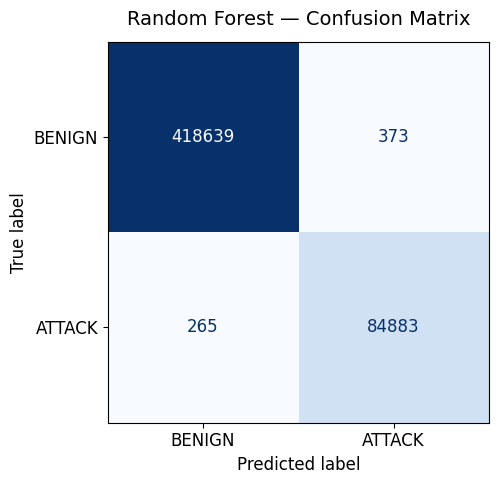

Saved: rf_confusion_matrix.png


In [20]:
#Confusion Matrix Plot

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(cm_rf, display_labels=["BENIGN", "ATTACK"])\
    .plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Random Forest — Confusion Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_confusion_matrix.png")

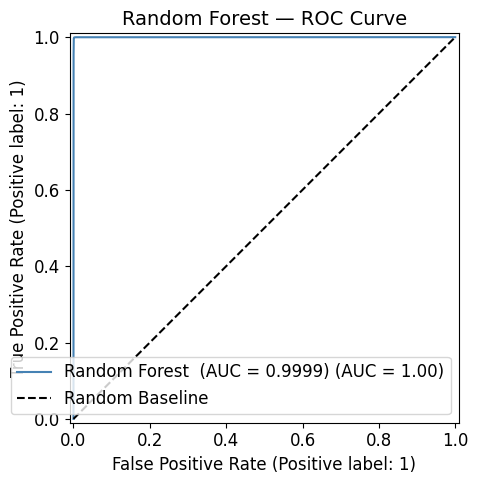

Saved: rf_roc_curve.png


In [21]:
#ROC Curve

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,
    ax=ax,
    name=f"Random Forest  (AUC = {roc_auc_rf:.4f})",
    color="steelblue"
)
ax.plot([0, 1], [0, 1], "k--", label="Random Baseline")
ax.set_title("Random Forest — ROC Curve", fontsize=14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("rf_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_roc_curve.png")

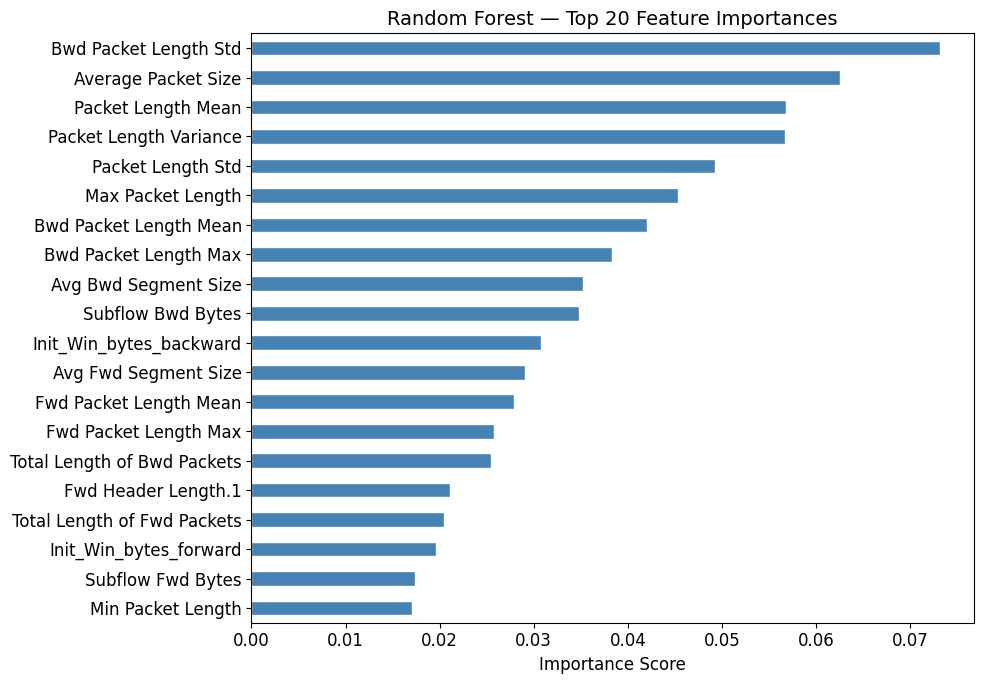

Saved: rf_feature_importance.png


In [22]:
#Feature Importance (Top 20)

import pandas as pd

importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Random Forest — Top 20 Feature Importances", fontsize=14)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_feature_importance.png")

In [23]:
#Store Results for Final Comparison Table

# Accumulate results — we'll add SVM and Isolation Forest here later
results = {}

results["Random Forest"] = {
    "Accuracy"  : round(accuracy_rf,  4),
    "Precision" : round(precision_rf, 4),
    "Recall"    : round(recall_rf,    4),
    "F1-Score"  : round(f1_rf,        4),
    "ROC-AUC"   : round(roc_auc_rf,   4),
    "FPR"       : round(fpr_rf,       4)
}

print("Results stored. Current table:")
print(pd.DataFrame(results).T.to_string())

Results stored. Current table:
               Accuracy  Precision  Recall  F1-Score  ROC-AUC     FPR
Random Forest    0.9987     0.9956  0.9969    0.9963   0.9999  0.0009


In [24]:
# ============================================================
# CHAPTER 4 — MODEL 2: SUPPORT VECTOR MACHINE
# ============================================================
# SVM does not scale to millions of samples due to its
# quadratic time complexity O(n²). A stratified random sample
# of 100,000 rows is used, preserving the original 83/17
# class distribution. This is standard practice in the
# literature when applying SVM to large network datasets
# (Buczak & Guven, 2016).
# ============================================================

from sklearn.svm import SVC
import time

# ── Stratified sample from training set only ─────────────────
# We sample from X_train/y_train so test set remains untouched
sample_idx = (
    pd.Series(y_train.values)
    .groupby(y_train.values)
    .apply(lambda x: x.sample(
        n=int(100000 * (len(x) / len(y_train))),
        random_state=42
    ))
    .explode()
    .index
    .get_level_values(1)
)

X_train_svm = X_train.iloc[sample_idx].reset_index(drop=True)
y_train_svm = y_train.iloc[sample_idx].reset_index(drop=True)

print(f"SVM training sample size : {len(X_train_svm):,}")
print(f"Class distribution:")
print(y_train_svm.value_counts())
print(f"\nBENIGN : {(y_train_svm==0).sum()/len(y_train_svm)*100:.1f}%")
print(f"ATTACK : {(y_train_svm==1).sum()/len(y_train_svm)*100:.1f}%")

SVM training sample size : 99,999
Class distribution:
Label
0    83110
1    16889
Name: count, dtype: int64

BENIGN : 83.1%
ATTACK : 16.9%


In [25]:
#Train SVM

svm_model = SVC(
    kernel="rbf",            # Radial Basis Function — best for non-linear data
    C=1.0,                   # regularisation (default, well-established)
    gamma="scale",           # scales with number of features automatically
    class_weight="balanced", # handles class imbalance
    probability=True,        # needed for ROC-AUC calculation
    random_state=42
)

print("Training SVM on 100,000 samples (this may take 5–15 minutes)...")
start = time.time()
svm_model.fit(X_train_svm, y_train_svm)
elapsed = time.time() - start

print(f"Training complete in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes).")

Training SVM on 100,000 samples (this may take 5–15 minutes)...
Training complete in 2657.0 seconds (44.3 minutes).


In [26]:
#Predict on Full Test Set

# Evaluate on the FULL 504,160-row test set (same as RF)
# This ensures a fair comparison across all models
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print(f"Predictions generated on {len(y_pred_svm):,} test samples.")

Predictions generated on 504,160 test samples.


In [27]:
#Compute All Metrics

cm_svm = confusion_matrix(y_test, y_pred_svm)
TN_s, FP_s, FN_s, TP_s = cm_svm.ravel()

accuracy_svm  = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm    = recall_score(y_test, y_pred_svm)
f1_svm        = f1_score(y_test, y_pred_svm)
roc_auc_svm   = roc_auc_score(y_test, y_prob_svm)
fpr_svm       = FP_s / (FP_s + TN_s)

print("=" * 48)
print("        SVM — EVALUATION RESULTS")
print("=" * 48)
print(f"  Accuracy   : {accuracy_svm:.4f}")
print(f"  Precision  : {precision_svm:.4f}")
print(f"  Recall     : {recall_svm:.4f}")
print(f"  F1-Score   : {f1_svm:.4f}")
print(f"  ROC-AUC    : {roc_auc_svm:.4f}")
print(f"  FPR        : {fpr_svm:.4f}   ← key metric")
print("=" * 48)
print(f"\n  Confusion Matrix:")
print(f"    TN = {TN_s:,}   FP = {FP_s:,}")
print(f"    FN = {FN_s:,}   TP = {TP_s:,}")
print()
print("Classification Report:")
print(classification_report(
    y_test, y_pred_svm,
    target_names=["BENIGN (0)", "ATTACK (1)"]
))

        SVM — EVALUATION RESULTS
  Accuracy   : 0.9567
  Precision  : 0.8208
  Recall     : 0.9510
  F1-Score   : 0.8811
  ROC-AUC    : 0.9913
  FPR        : 0.0422   ← key metric

  Confusion Matrix:
    TN = 401,331   FP = 17,681
    FN = 4,172   TP = 80,976

Classification Report:
              precision    recall  f1-score   support

  BENIGN (0)       0.99      0.96      0.97    419012
  ATTACK (1)       0.82      0.95      0.88     85148

    accuracy                           0.96    504160
   macro avg       0.91      0.95      0.93    504160
weighted avg       0.96      0.96      0.96    504160



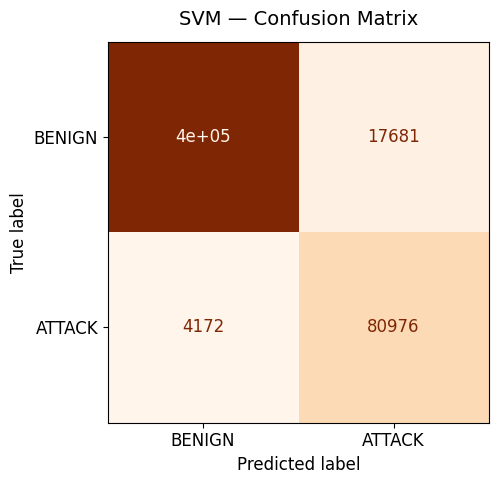

Saved: svm_confusion_matrix.png


In [28]:
#Confusion Matrix Plot

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(cm_svm, display_labels=["BENIGN", "ATTACK"])\
    .plot(ax=ax, colorbar=False, cmap="Oranges")

ax.set_title("SVM — Confusion Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("svm_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: svm_confusion_matrix.png")

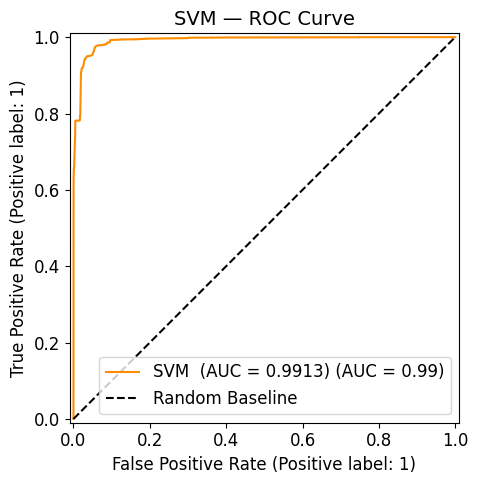

Saved: svm_roc_curve.png


In [29]:
#ROC Curve

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob_svm,
    ax=ax,
    name=f"SVM  (AUC = {roc_auc_svm:.4f})",
    color="darkorange"
)
ax.plot([0, 1], [0, 1], "k--", label="Random Baseline")
ax.set_title("SVM — ROC Curve", fontsize=14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("svm_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: svm_roc_curve.png")

In [30]:
#Store Results

results["SVM"] = {
    "Accuracy"  : round(accuracy_svm,  4),
    "Precision" : round(precision_svm, 4),
    "Recall"    : round(recall_svm,    4),
    "F1-Score"  : round(f1_svm,        4),
    "ROC-AUC"   : round(roc_auc_svm,   4),
    "FPR"       : round(fpr_svm,       4)
}

print("Results stored. Current table:")
print(pd.DataFrame(results).T.to_string())

Results stored. Current table:
               Accuracy  Precision  Recall  F1-Score  ROC-AUC     FPR
Random Forest    0.9987     0.9956  0.9969    0.9963   0.9999  0.0009
SVM              0.9567     0.8208  0.9510    0.8811   0.9913  0.0422


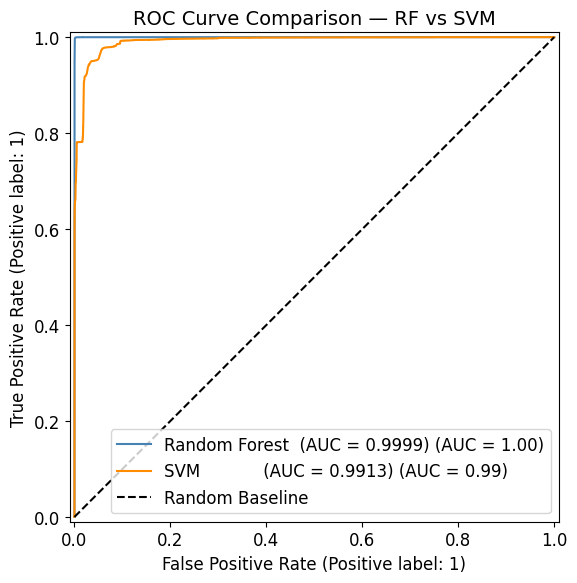

Saved: roc_comparison_rf_svm.png


In [31]:
#Combined ROC Curve (RF + SVM so far)

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,
    ax=ax, name=f"Random Forest  (AUC = {roc_auc_rf:.4f})",
    color="steelblue"
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_svm,
    ax=ax, name=f"SVM            (AUC = {roc_auc_svm:.4f})",
    color="darkorange"
)
ax.plot([0, 1], [0, 1], "k--", label="Random Baseline")
ax.set_title("ROC Curve Comparison — RF vs SVM", fontsize=14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_comparison_rf_svm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_comparison_rf_svm.png")

In [32]:
# ============================================================
# CHAPTER 4 — MODEL 3: ISOLATION FOREST
# ============================================================
# Isolation Forest is an unsupervised anomaly detection model.
# It learns the structure of NORMAL (benign) traffic only,
# then flags deviations as anomalies (attacks).
#
# Key difference from RF and SVM:
#   - Does NOT use labels during training
#   - Trained on BENIGN samples only
#   - contamination parameter = expected attack proportion
# ============================================================

#Train Isolation Forest

# ============================================================
# CHAPTER 4 — MODEL 3: ISOLATION FOREST
# ============================================================

from sklearn.ensemble import IsolationForest

# ── Fix index alignment before filtering ─────────────────────
y_train_aligned = y_train.reset_index(drop=True)

# ── Train on benign traffic only (unsupervised) ───────────────
X_train_benign = X_train[y_train_aligned == 0]

print(f"Training Isolation Forest on benign samples only...")
print(f"Benign training samples : {len(X_train_benign):,}")

iforest_model = IsolationForest(
    n_estimators=100,
    contamination=0.169,   # matches observed attack rate (16.9%)
    random_state=42,
    n_jobs=-1
)

start = time.time()
iforest_model.fit(X_train_benign)
elapsed = time.time() - start

print(f"Training complete in {elapsed:.1f} seconds.")

Training Isolation Forest on benign samples only...
Benign training samples : 1,676,045
Training complete in 15.0 seconds.


In [33]:
#Predict & Convert Scores

# Isolation Forest returns: +1 = normal, -1 = anomaly
# We convert to: 0 = BENIGN, 1 = ATTACK  (matches our label scheme)

raw_preds = iforest_model.predict(X_test)
y_pred_if = (raw_preds == -1).astype(int)

# Anomaly scores — more negative = more anomalous
# We invert and normalise for ROC-AUC compatibility
raw_scores   = iforest_model.score_samples(X_test)
y_prob_if    = -raw_scores    # higher = more likely attack

print(f"Predictions generated on {len(y_pred_if):,} test samples.")
print(f"Flagged as ATTACK : {y_pred_if.sum():,}")
print(f"Flagged as BENIGN : {(y_pred_if==0).sum():,}")

Predictions generated on 504,160 test samples.
Flagged as ATTACK : 122,970
Flagged as BENIGN : 381,190


In [34]:
#Compute All Metrics

cm_if = confusion_matrix(y_test, y_pred_if)
TN_i, FP_i, FN_i, TP_i = cm_if.ravel()

accuracy_if  = accuracy_score(y_test, y_pred_if)
precision_if = precision_score(y_test, y_pred_if)
recall_if    = recall_score(y_test, y_pred_if)
f1_if        = f1_score(y_test, y_pred_if)
roc_auc_if   = roc_auc_score(y_test, y_prob_if)
fpr_if       = FP_i / (FP_i + TN_i)

print("=" * 48)
print("   ISOLATION FOREST — EVALUATION RESULTS")
print("=" * 48)
print(f"  Accuracy   : {accuracy_if:.4f}")
print(f"  Precision  : {precision_if:.4f}")
print(f"  Recall     : {recall_if:.4f}")
print(f"  F1-Score   : {f1_if:.4f}")
print(f"  ROC-AUC    : {roc_auc_if:.4f}")
print(f"  FPR        : {fpr_if:.4f}   ← key metric")
print("=" * 48)
print(f"\n  Confusion Matrix:")
print(f"    TN = {TN_i:,}   FP = {FP_i:,}")
print(f"    FN = {FN_i:,}   TP = {TP_i:,}")
print()
print("Classification Report:")
print(classification_report(
    y_test, y_pred_if,
    target_names=["BENIGN (0)", "ATTACK (1)"]
))

   ISOLATION FOREST — EVALUATION RESULTS
  Accuracy   : 0.7925
  Precision  : 0.4208
  Recall     : 0.6078
  F1-Score   : 0.4973
  ROC-AUC    : 0.8111
  FPR        : 0.1700   ← key metric

  Confusion Matrix:
    TN = 347,792   FP = 71,220
    FN = 33,398   TP = 51,750

Classification Report:
              precision    recall  f1-score   support

  BENIGN (0)       0.91      0.83      0.87    419012
  ATTACK (1)       0.42      0.61      0.50     85148

    accuracy                           0.79    504160
   macro avg       0.67      0.72      0.68    504160
weighted avg       0.83      0.79      0.81    504160



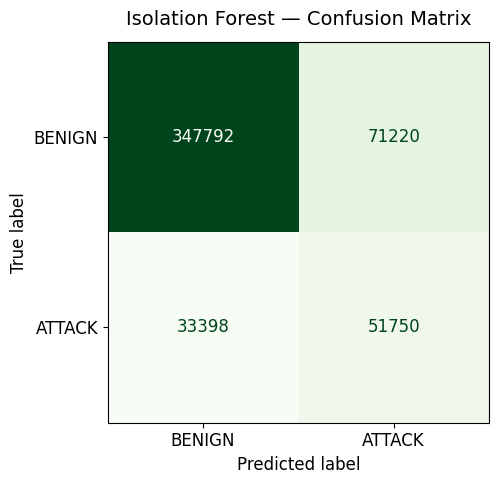

Saved: if_confusion_matrix.png


In [35]:
# Confusion Matrix Plot

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(cm_if, display_labels=["BENIGN", "ATTACK"])\
    .plot(ax=ax, colorbar=False, cmap="Greens")

ax.set_title("Isolation Forest — Confusion Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("if_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: if_confusion_matrix.png")

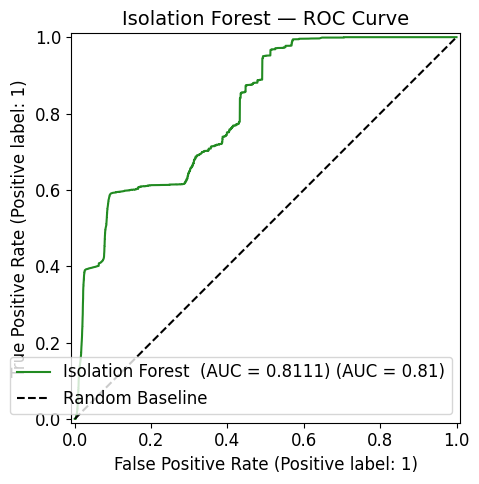

Saved: if_roc_curve.png


In [36]:
# ROC Curve

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test, y_prob_if,
    ax=ax,
    name=f"Isolation Forest  (AUC = {roc_auc_if:.4f})",
    color="forestgreen"
)
ax.plot([0, 1], [0, 1], "k--", label="Random Baseline")
ax.set_title("Isolation Forest — ROC Curve", fontsize=14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("if_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: if_roc_curve.png")

In [37]:
# Store Results

results["Isolation Forest"] = {
    "Accuracy"  : round(accuracy_if,  4),
    "Precision" : round(precision_if, 4),
    "Recall"    : round(recall_if,    4),
    "F1-Score"  : round(f1_if,        4),
    "ROC-AUC"   : round(roc_auc_if,   4),
    "FPR"       : round(fpr_if,       4)
}

print("Results stored. Current table:")
print(pd.DataFrame(results).T.to_string())

Results stored. Current table:
                  Accuracy  Precision  Recall  F1-Score  ROC-AUC     FPR
Random Forest       0.9987     0.9956  0.9969    0.9963   0.9999  0.0009
SVM                 0.9567     0.8208  0.9510    0.8811   0.9913  0.0422
Isolation Forest    0.7925     0.4208  0.6078    0.4973   0.8111  0.1700


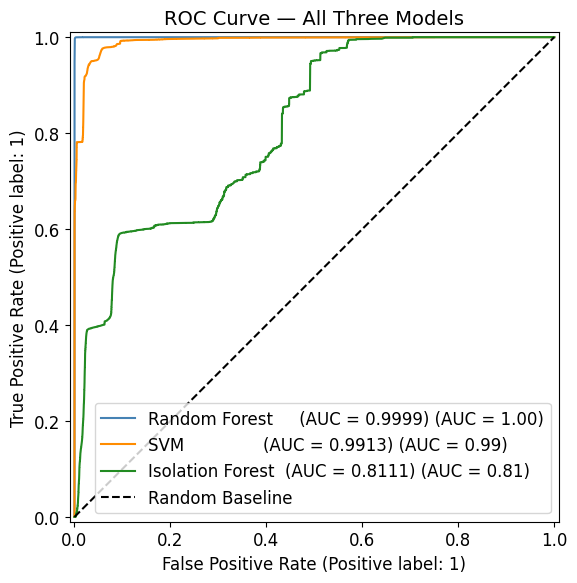

Saved: roc_comparison_all.png


In [38]:
# Full Three-Model ROC Comparison

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,
    ax=ax, name=f"Random Forest     (AUC = {roc_auc_rf:.4f})",
    color="steelblue"
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_svm,
    ax=ax, name=f"SVM               (AUC = {roc_auc_svm:.4f})",
    color="darkorange"
)
RocCurveDisplay.from_predictions(
    y_test, y_prob_if,
    ax=ax, name=f"Isolation Forest  (AUC = {roc_auc_if:.4f})",
    color="forestgreen"
)
ax.plot([0, 1], [0, 1], "k--", label="Random Baseline")
ax.set_title("ROC Curve — All Three Models", fontsize=14)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_comparison_all.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_comparison_all.png")

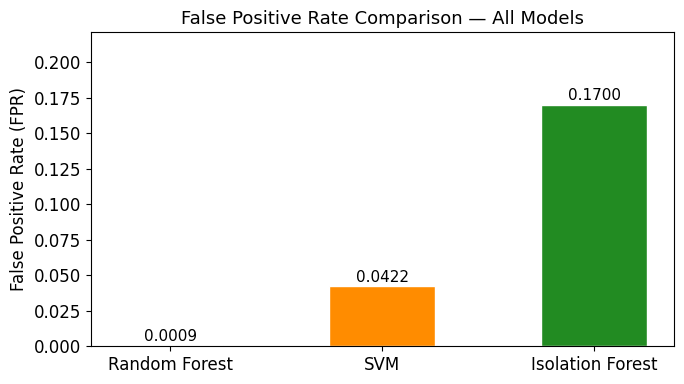

Saved: fpr_comparison.png


In [39]:
# FPR Bar Chart (Key Research Metric)

fig, ax = plt.subplots(figsize=(7, 4))

models = list(results.keys())
fprs   = [results[m]["FPR"] for m in models]
colors = ["steelblue", "darkorange", "forestgreen"]

bars = ax.bar(models, fprs, color=colors, edgecolor="white", width=0.5)
ax.set_ylabel("False Positive Rate (FPR)")
ax.set_title("False Positive Rate Comparison — All Models", fontsize=13)
ax.set_ylim(0, max(fprs) * 1.3)

# Label each bar with its value
for bar, val in zip(bars, fprs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{val:.4f}", ha="center", va="bottom", fontsize=11
    )

plt.tight_layout()
plt.savefig("fpr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fpr_comparison.png")

In [40]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_model,      "../models/rf_model.pkl")
joblib.dump(svm_model,     "../models/svm_model.pkl")
joblib.dump(iforest_model, "../models/iforest_model.pkl")
joblib.dump(scaler,        "../models/scaler.pkl")

print("All models saved to ../models/")

All models saved to ../models/
